# 🚀 Practice Day 14

**📅 Date:** 2026-09-25  
**📁 Category:** Phase 4 · 캡스톤 2 - 구독 서비스 이탈 Churn 분석 (Round 1/3)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Calculate a churn rate and break it down by segment (이탈률을 계산하고 세그먼트별로 나눠보기)
- Find out which behaviors are associated with churn (어떤 행동 패턴이 이탈과 관련 있는지 찾기)
- Capstone file: fewer hints than usual, more of the analysis approach is up to you (캡스톤 파일: 평소보다 힌트가 적고, 분석 방식 자체를 더 많이 직접 결정)

---
# 📂 Dataset

**Dataset Name:** OTT Streaming Subscription Data (OTT 스트리밍 구독 데이터)

**Source:** Synthetically generated for practice, fixed random seed (연습용으로 코드에서 직접 생성, seed 고정)

**Description:** 220 subscribers with plan type (Basic/Standard/Premium), tenure in months, average weekly watch hours, number of support tickets filed, and whether they churned (1) or stayed (0). Churn is built to genuinely relate to engagement (watch hours), friction (support tickets), loyalty (tenure), and plan type - not random.
(구독자 220명 — 요금제(Basic/Standard/Premium), 구독 개월수(tenure), 주간 평균 시청시간, 문의(support ticket) 건수, 이탈 여부(churned: 1=이탈, 0=유지) 포함. 이탈은 무작위가 아니라 이용 참여도(시청시간), 마찰(문의 건수), 충성도(구독 기간), 요금제와 실제로 관련이 있도록 설계했습니다.)

## Dataset Preview

In [49]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)

n_customers = 220

plan_type = np.random.choice(['Basic', 'Standard', 'Premium'], size=n_customers, p=[0.40, 0.40, 0.20])
tenure_months = np.random.randint(1, 37, size=n_customers)
avg_watch_hours_per_week = np.round(np.clip(np.random.gamma(shape=2.5, scale=3.0, size=n_customers), 0, 30), 1)
support_tickets = np.random.poisson(lam=0.8, size=n_customers)

# churn probability genuinely depends on engagement, friction, tenure, and plan
plan_churn_adjustment = np.where(plan_type == 'Premium', -1.0, np.where(plan_type == 'Basic', 0.6, 0.0))
churn_logit = (
    -0.2
    - 0.12 * avg_watch_hours_per_week
    + 0.40 * support_tickets
    - 0.03 * tenure_months
    + plan_churn_adjustment
)
churn_prob = 1 / (1 + np.exp(-churn_logit))
churned = (np.random.random(n_customers) < churn_prob).astype(int)

df = pd.DataFrame({
    'customer_id': [f'CUST-{i+1:04d}' for i in range(n_customers)],
    'plan_type': plan_type,
    'tenure_months': tenure_months,
    'avg_watch_hours_per_week': avg_watch_hours_per_week,
    'support_tickets': support_tickets,
    'churned': churned,
})

df.head()

,customer_id,plan_type,tenure_months,avg_watch_hours_per_week,support_tickets,churned
0,CUST-0001,Basic,17,5.1,2,0
1,CUST-0002,Premium,33,7.7,1,0
2,CUST-0003,Standard,12,8.0,2,1
3,CUST-0004,Standard,22,17.1,0,0
4,CUST-0005,Basic,22,11.3,1,1


## Dataset Information

In [50]:
# Dataset Information
print(df.shape)
df.info()
df.describe()

(220, 6)
<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               220 non-null    str    
 1   plan_type                 220 non-null    str    
 2   tenure_months             220 non-null    int64  
 3   avg_watch_hours_per_week  220 non-null    float64
 4   support_tickets           220 non-null    int64  
 5   churned                   220 non-null    int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 10.4 KB


,tenure_months,avg_watch_hours_per_week,support_tickets,churned
count,220.000000,220.000000,220.000000,220.000
mean,20.809091,7.670909,0.872727,0.250
std,10.443145,4.754750,0.917701,0.434
min,1.000000,0.600000,0.000000,0.000
25%,12.000000,3.975000,0.000000,0.000
50%,23.000000,6.800000,1.000000,0.000
75%,30.000000,10.800000,1.000000,0.250
max,36.000000,25.000000,4.000000,1.000


---
# ❓ Business Questions

1. What is the overall churn rate? (전체 이탈률은?)
2. How do average watch hours and support tickets differ between churned and retained customers? (해지 고객과 유지 고객 간 평균 시청시간과 문의 건수는 어떻게 다른가?)
3. What is the churn rate for each subscription plan? (요금제별 이탈률은?)
4. How does churn rate compare across plan types? (요금제별 이탈률을 비교하면 어떤 모습인가?)
5. How does the distribution of watch hours differ between churned and retained customers? (해지/유지 고객 간 시청시간 분포 차이는 어떤 모습인가?)

---
# 🛠 Skills Used
- [x] Python
- [ ] NumPy
- [x] Pandas — `value_counts(normalize=True)`, `groupby().agg()`, `reindex`
  (비율 계산, 그룹별 집계, 순서 지정)
- [ ] SQL
- [x] Matplotlib — `plt.subplots`, `ax.bar`
  (막대 차트)
- [x] Other: Seaborn — `sns.boxplot`
  (박스플롯) 

---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 0
  (결측 없음)
- [x] Duplicate Rows — 0
  (중복 행 없음)
- [x] Wrong Data Types — `churned` is int (0/1); no fix needed
  (churned는 0/1 정수. 수정 불필요)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [51]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
customer_id                 0
plan_type                   0
tenure_months               0
avg_watch_hours_per_week    0
support_tickets             0
churned                     0
dtype: int64

Duplicate rows: 0

Dtypes
customer_id                     str
plan_type                       str
tenure_months                 int64
avg_watch_hours_per_week    float64
support_tickets               int64
churned                       int64
dtype: object

Column names
['customer_id', 'plan_type', 'tenure_months', 'avg_watch_hours_per_week', 'support_tickets', 'churned']

Text columns — unique counts
customer_id    220
plan_type        3
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** What is the overall churn rate? (전체 이탈률은?)

**Result:** The overall churn rate is **25%** (0.25). The other **75%** of customers stayed (0.75).
(전체 이탈률은 25%(0.25). 나머지 75%는 유지(0.75))

**Insight:** One in four customers churned. The next questions look at which groups are above or below this 25%.
(4명 중 1명이 이탈. 다음 질문에서 어느 그룹이 이 25%보다 높거나 낮은지 봄)

In [52]:
# Question 1: Overall churn rate = share of customers with churned == 1

overall_churn = df['churned'].value_counts(normalize=True).reset_index()
overall_churn

,churned,proportion
0,0,0.75
1,1,0.25


## Question 2

**Question:** How do average watch hours and support tickets differ between churned and retained customers? (해지 고객과 유지 고객 간 평균 시청시간과 문의 건수는 어떻게 다른가?)

**Result:** Retained customers (165) watch **8.28** hours per week and file **0.77** support tickets on average. Churned customers (55) watch **5.83** hours and file **1.18** tickets.
(유지 고객(165명)은 평균 주 8.28시간 시청, 문의 0.77건. 이탈 고객(55명)은 5.83시간, 문의 1.18건)

**Insight:** Churned customers watch less and file more support tickets than retained customers.
(이탈 고객은 유지 고객보다 시청 시간이 적고 문의 건수가 많음)

In [53]:
# Question 2: Compare avg_watch_hours_per_week and support_tickets, grouped by churned

churn_compare = df.groupby('churned').agg(
    avg_watch_hours_per_week=('avg_watch_hours_per_week', 'mean'),
    avg_support_tickets=('support_tickets', 'mean'),
    customer_count=('customer_id', 'count'),
).reset_index()

churn_compare

,churned,avg_watch_hours_per_week,avg_support_tickets,customer_count
0,0,8.284848,0.769697,165
1,1,5.829091,1.181818,55


## Question 3

**Question:** What is the churn rate for each subscription plan? (요금제별 이탈률은?)

**Result:** Churn rate by plan: Basic **30.30%**, Standard **28.57%**, Premium **6.82%**.
(요금제별 이탈률: Basic 30.30%, Standard 28.57%, Premium 6.82%)

**Insight:** Basic and Standard are close to each other and above the overall **25%**. Premium is far lower.
(Basic과 Standard는 비슷하고 전체 25%보다 높음. Premium은 훨씬 낮음)

In [54]:
# Question 3: Churn rate (mean of churned) for each plan_type

plan_churn = (df.groupby('plan_type')['churned'].mean() * 100).round(2).rename('churn_rate').reset_index()
plan_churn


,plan_type,churn_rate
0,Basic,30.30
1,Premium,6.82
2,Standard,28.57


---
# 📈 Visualization

**Chart 1:** Churn rate by plan type (bar chart) — 요금제별 이탈률

*Interpretation:* Bars go in plan order (Basic, Standard, Premium). Basic (about **30%**) and Standard (about **29%**) are about the same height, and Premium (about **7%**) is much lower.
(요금제 순서(Basic, Standard, Premium)대로 나열. Basic(약 30%)과 Standard(약 29%)는 비슷한 높이이고 Premium(약 7%)은 훨씬 낮음)

---

**Chart 2:** Watch hours distribution, churned vs. retained (boxplot) — 이탈/유지 고객 시청시간 분포

*Interpretation:* Retained customers have a higher median (about **7** hours vs about **5**) and a longer box, so their watch hours are more spread out. Churned customers are lower and more compressed. Retained has one outlier dot at the top (about **25** hours).
(유지 고객의 중앙값이 더 높고(약 7시간 vs 약 5시간) 박스도 더 길어 시청 시간이 더 넓게 퍼져 있음. 이탈 고객은 낮고 더 모여 있음. 유지 쪽 위에 이상치 점 1개(약 25시간))

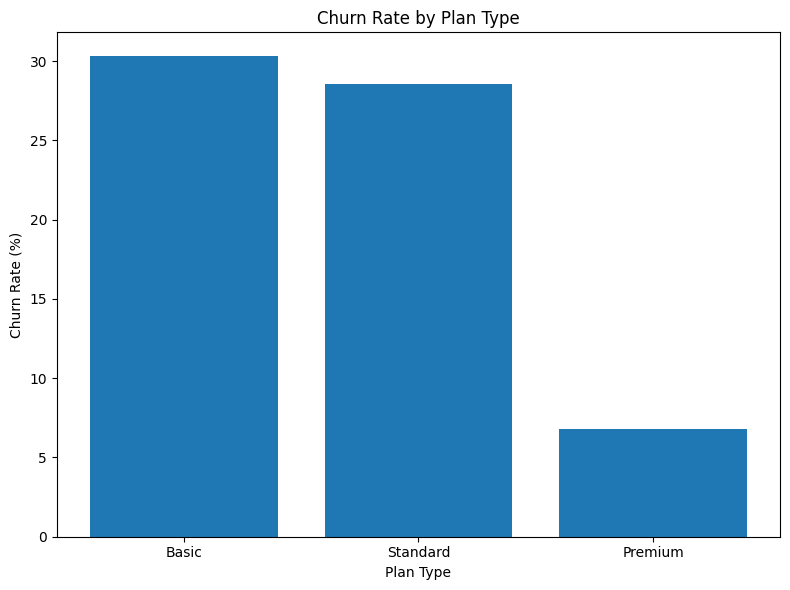

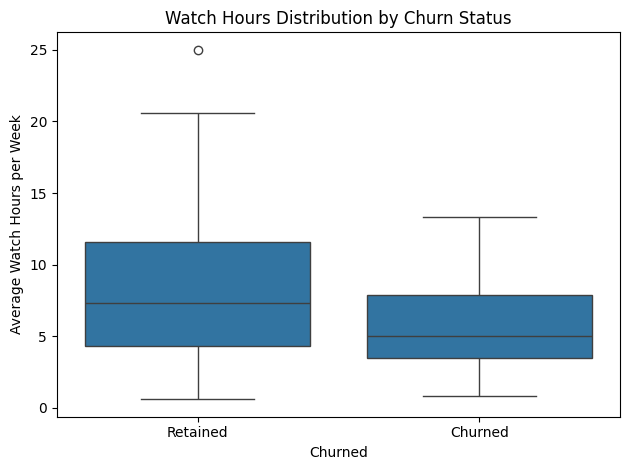

In [55]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: Churn rate by plan type (bar chart)
chart1 = (df.groupby('plan_type')['churned'].mean() * 100).round(2).reindex(['Basic', 'Standard', 'Premium'])
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(chart1.index, chart1.values)
ax.set_title('Churn Rate by Plan Type')
ax.set_xlabel('Plan Type')
ax.set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

# Chart 2: Watch hours distribution, churned vs retained (boxplot)
ax = sns.boxplot(x='churned', y='avg_watch_hours_per_week', data=df)
ax.set_title('Watch Hours Distribution by Churn Status')
ax.set_xlabel('Churned')
ax.set_ylabel('Average Watch Hours per Week')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Retained', 'Churned'])
plt.tight_layout()
plt.show()


---
# 💼 Business Insights
**What did I discover?**

- The overall churn rate is **25%**. Basic (**30.30%**) and Standard (**28.57%**) are above it, and Premium (**6.82%**) is far below it.
  (전체 이탈률은 25%. Basic 30.30%, Standard 28.57%는 그보다 높고 Premium 6.82%는 훨씬 낮음)
- Churned customers watch less (**5.83** vs **8.28** hours per week) and file more support tickets (**1.18** vs **0.77**) than retained customers.
  (이탈 고객은 유지 고객보다 시청이 적고(주 5.83 vs 8.28시간) 문의가 많음(1.18 vs 0.77))
- On the boxplot, retained customers have a higher median watch time (about **7** vs about **5** hours).
  (박스플롯에서 유지 고객의 시청 시간 중앙값이 더 높음(약 7시간 vs 약 5시간))
  

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Focus retention on Basic and Standard, since their churn is near **30%** while Premium is only **6.82%**.
   (이탈이 30% 가까운 Basic과 Standard에 리텐션을 집중. Premium은 6.82%)
2. Treat low watch time as an early warning sign, because churned customers watch less. Recommend content to low-watch customers.
   (이탈 고객이 시청이 적으니 낮은 시청 시간을 경고 신호로 보고, 시청이 적은 고객에게 콘텐츠 추천)
3. Follow up on customers with more support tickets, because churned customers filed more of them.
   (이탈 고객이 문의가 많았으니 문의가 많은 고객을 사후 관리)
   

---
# ❌ Mistakes
**What mistakes did I make today?**

- I used the same variable name `data` in Q1 to Q3, so each cell overwrote the last, and Chart 1 depended on the Q3 value. I gave each question its own name (`overall_churn`, `churn_compare`, `plan_churn`) and recomputed Chart 1 inside its own cell.
  (Q1~Q3에서 같은 변수 이름 data를 써서 셀마다 덮어쓰였고 Chart 1이 Q3 값에 의존함. 질문마다 고유한 이름을 주고 Chart 1은 자기 셀 안에서 다시 계산)
- The bars were in alphabetical order (Basic, Premium, Standard). I put them in plan order with `reindex`.
  (막대가 알파벳 순(Basic, Premium, Standard). reindex로 요금제 순서로)
- The y-axis label did not say the values are percent. I changed it to `Churn Rate (%)`.
  (y축 라벨에 퍼센트라는 단위가 없었음. Churn Rate (%)로 변경)
  

---
# ✅ What I Learned
**Today's biggest lesson**

- Churn rate is the share of customers who left. With a 0/1 `churned` column, the mean of that column is the churn rate.
  (이탈률은 떠난 고객의 비율. churned가 0/1이면 그 열의 평균이 이탈률)
- `groupby('churned')` then `mean` compares behavior (watch hours, tickets) between churned and retained customers.
  (churned로 groupby 후 mean으로 이탈/유지 고객의 행동을 비교)
- `sns.boxplot(x=group, y=value, data=df)` shows the whole distribution of each group, so no aggregation is needed first.
  (boxplot은 그룹별 분포 전체를 보여주기 때문에 먼저 집계할 필요가 없음)
  

---
# 🧠 Reflection

**What was difficult?**
Knowing what to apply to the grouped data for the boxplot.
(박스플롯에서 그룹 데이터에 무엇을 적용해야 하는지 파악)

**Why?**
I thought a boxplot needed an aggregation like `mean`, but it takes the raw values.
(박스플롯도 mean 같은 집계가 필요하다고 생각했는데 원본 값을 받음)

**How did I solve it?**
Used `sns.boxplot(x='churned', y='avg_watch_hours_per_week', data=df)` and changed the 0/1 tick labels to Retained/Churned.
(sns.boxplot에 원본 df를 넣고 0/1 눈금을 Retained/Churned로 바꿈)

**What would I do differently next time?**
Make each chart cell independent of earlier cells, and think about the bar order before plotting.
(차트 셀이 앞 셀에 의존하지 않게 하고, 그리기 전에 막대 순서를 생각)



---
# ⭐ Self Evaluation

**Understanding**  
★★★★★★★☆☆☆  
Churn rate and group comparison are clear.  
(이탈률 계산과 집단 비교는 이해)

**Confidence**  
★★★★★★☆☆☆☆  

**Difficulty**  
★★★★☆☆☆☆☆☆  
No new tools, so it was relatively easy.  
(새로운 도구는 없어 비교적 쉬웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 15 — Pandas basics (Round 2/5)
  (Pandas 기초 복습)
  